In [14]:
from pathlib import Path
import pandas as pd

# Use existing `outputs` variable if it exists; otherwise default to ./outputs
outputs_path = Path(outputs) if "outputs" in globals() else Path("outputs")

marginal_parts = []
pnls_parts = []
risk_parts = []
stress_risk_parts = []

for date_dir in sorted(outputs_path.iterdir()):
    if not date_dir.is_dir():
        continue

    try:
        calc_date = pd.to_datetime(date_dir.name, format="%Y%m%d")
    except ValueError:
        continue

    marginal_file = date_dir / "marginal_risk.csv"
    pnls_file = date_dir / "pnls.csv"
    risk_file = date_dir / "risk.csv"
    stress_risk_file = date_dir / "stress_risk.csv"

    if not (marginal_file.exists() and pnls_file.exists() and risk_file.exists() and stress_risk_file.exists()):
        continue

    marginal_df = pd.read_csv(marginal_file)
    marginal_df["date"] = calc_date
    marginal_parts.append(marginal_df)

    pnl_df = pd.read_csv(pnls_file)
    pnl_df["date"] = calc_date
    pnls_parts.append(pnl_df)

    risk_df = pd.read_csv(risk_file)
    risk_df["date"] = calc_date
    risk_parts.append(risk_df)

    stress_df = pd.read_csv(stress_risk_file)
    stress_df["date"] = calc_date
    stress_risk_parts.append(stress_df)

marginal_risk_df = pd.concat(marginal_parts, ignore_index=True) if marginal_parts else pd.DataFrame()
pnls_df = pd.concat(pnls_parts, ignore_index=True) if pnls_parts else pd.DataFrame()
risk_df = pd.concat(risk_parts, ignore_index=True) if risk_parts else pd.DataFrame()
stress_risk_df = pd.concat(stress_risk_parts, ignore_index=True) if stress_risk_parts else pd.DataFrame()

print(f"Loaded {len(risk_parts)} date folders with complete files.")
print(f"marginal_risk_df shape: {marginal_risk_df.shape}")
print(f"pnls_df shape: {pnls_df.shape}")
print(f"risk_df shape: {risk_df.shape}")
print(f"stress_risk_df shape: {stress_risk_df.shape}")

Loaded 92 date folders with complete files.
marginal_risk_df shape: (214, 6)
pnls_df shape: (920000, 2)
risk_df shape: (92, 6)
stress_risk_df shape: (92, 5)


<Axes: xlabel='date'>

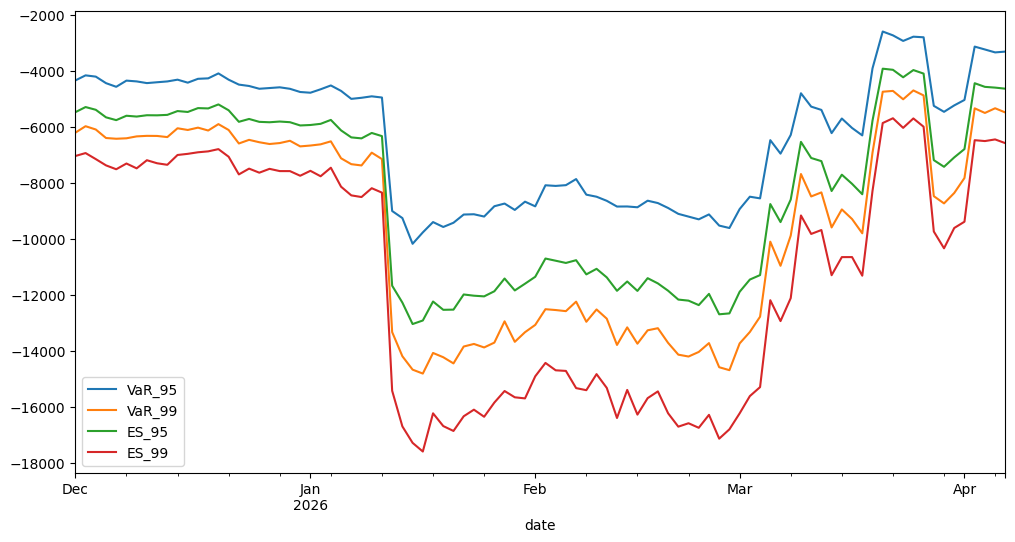

In [15]:
risk_df.plot(x="date", y=["VaR_95", "VaR_99", "ES_95", "ES_99"], figsize=(12, 6))

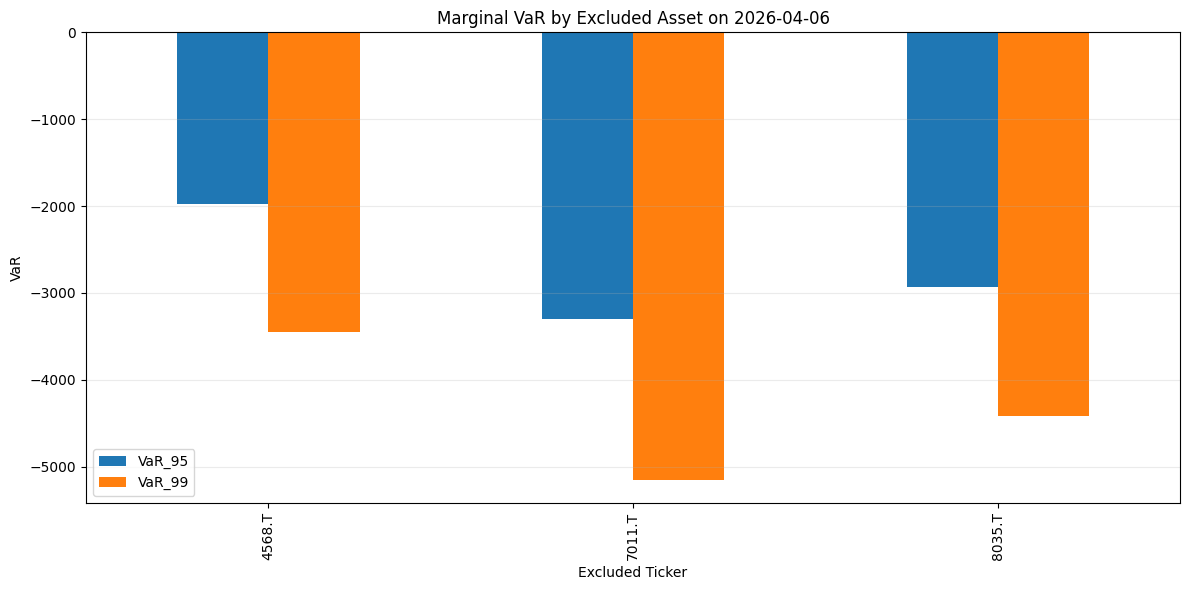

,VaR_95,VaR_99
excluded_ticker,,
4568.T,-1977.348717,-3449.269925
7011.T,-3301.072643,-5155.200712
8035.T,-2927.571030,-4421.172861


In [16]:
import matplotlib.pyplot as plt

# Pick any date that exists in marginal_risk_df
selected_date = pd.to_datetime("2026-04-06")

if marginal_risk_df.empty:
    raise ValueError("marginal_risk_df is empty. Run Cell 1 first.")

tmp = marginal_risk_df.copy()
tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()
selected = tmp[tmp["date"] == selected_date.normalize()].copy()

if selected.empty:
    available = sorted(tmp["date"].dt.strftime("%Y-%m-%d").unique())
    raise ValueError(f"No marginal data for {selected_date:%Y-%m-%d}. Available dates: {available[:10]}...")

# Plot all VaR columns available in marginal_risk_df for the selected date
var_cols = [c for c in selected.columns if "VaR" in c]
if not var_cols:
    raise ValueError("No VaR columns found in marginal_risk_df.")

plot_df = selected.set_index("excluded_ticker")[var_cols].sort_index()
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title(f"Marginal VaR by Excluded Asset on {selected_date:%Y-%m-%d}")
plt.xlabel("Excluded Ticker")
plt.ylabel("VaR")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plot_df

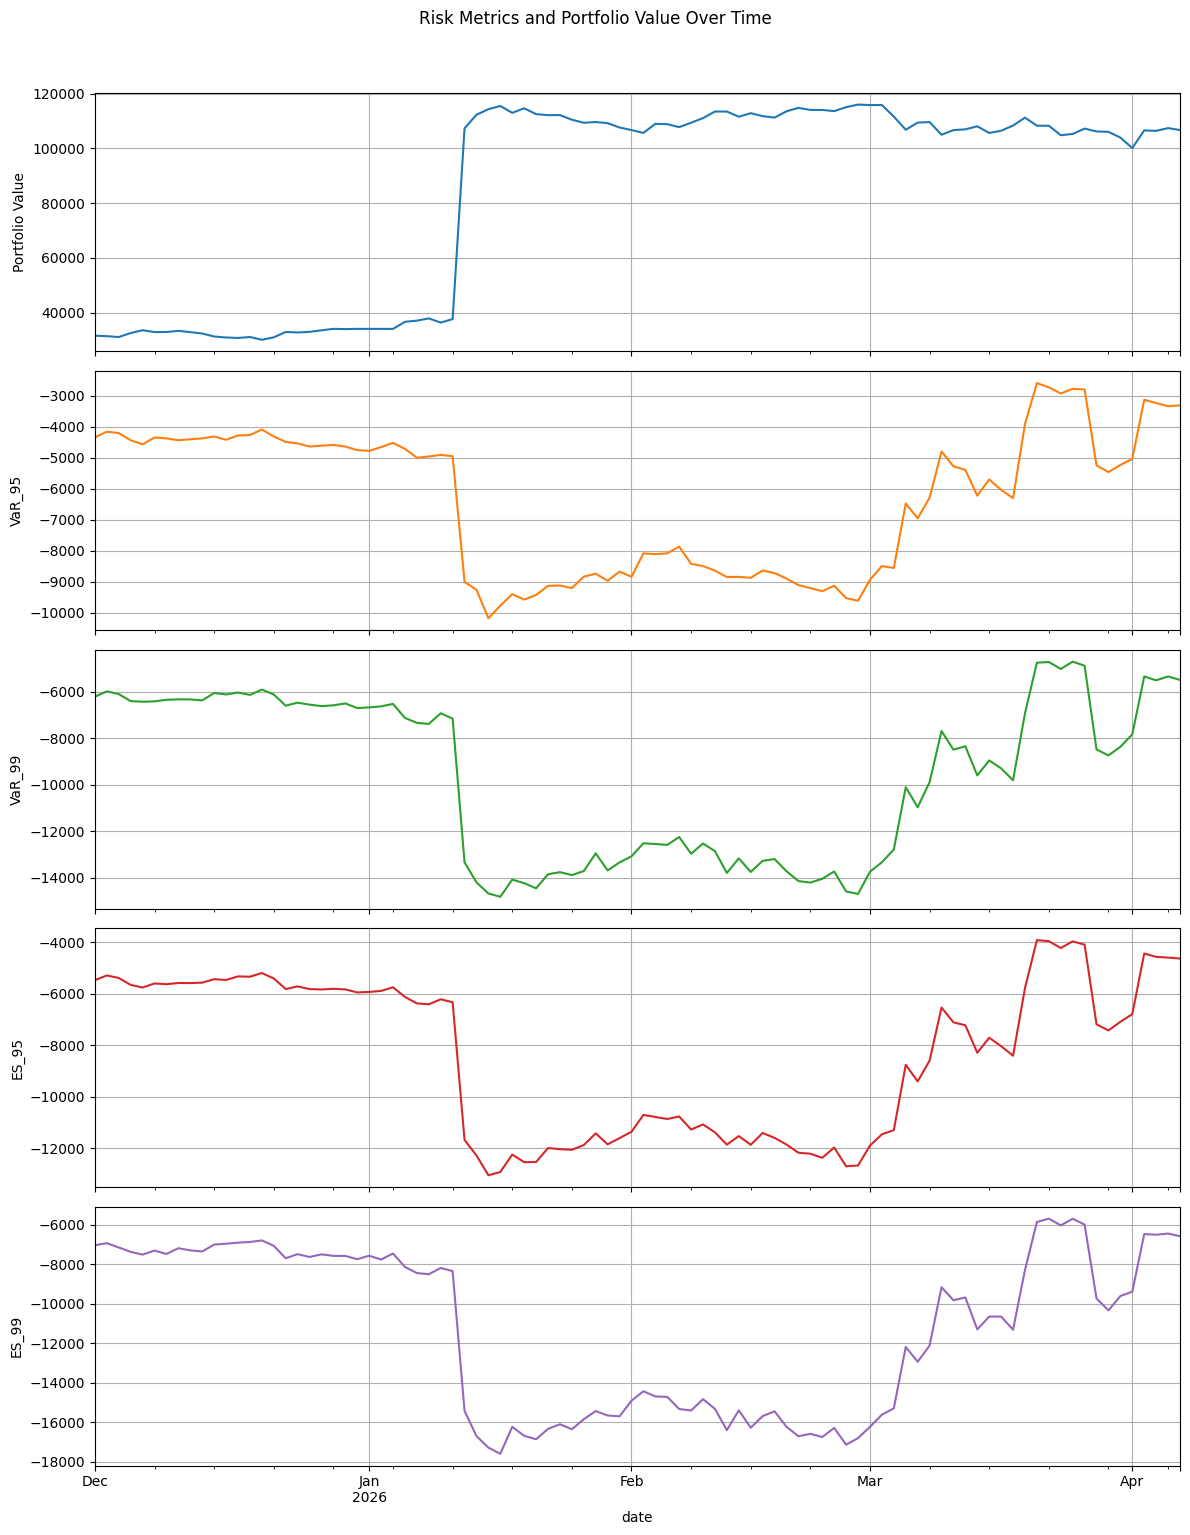

,date,Portfolio Value,VaR_95,VaR_99,ES_95,ES_99
87,2026-04-01,100131.0,-5040.696299,-7827.052916,-6793.991309,-9387.569881
88,2026-04-02,106573.0,-3136.857913,-5340.321239,-4444.079524,-6477.190329
89,2026-04-03,106415.5,-3239.688033,-5505.211930,-4573.945126,-6508.960222
90,2026-04-06,107418.5,-3344.002459,-5337.898399,-4600.747508,-6450.115786
91,2026-04-07,106707.0,-3315.292947,-5488.565817,-4638.995373,-6583.661279


In [18]:
import matplotlib.pyplot as plt

if risk_df.empty:
    raise ValueError("risk_df is empty. Run Cell 1 first.")

tmp = risk_df.copy()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp = tmp.sort_values("date")

value_cols = [c for c in tmp.columns if c != "date" and pd.api.types.is_numeric_dtype(tmp[c])]
if not value_cols:
    raise ValueError("No numeric columns found in risk_df to plot.")

axarr = tmp.plot(
    x="date",
    y=value_cols,
    subplots=True,
    figsize=(12, 3 * len(value_cols)),
    legend=False,
    sharex=True,
    grid=True
 )

for ax, col in zip(axarr, value_cols):
    ax.set_ylabel(col)

plt.suptitle("Risk Metrics and Portfolio Value Over Time", y=1.02)
plt.tight_layout()
plt.show()

tmp[["date"] + value_cols].tail()